BLOCK 1 — Imports & Data Load + Cleaning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a2e",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "axes.titlecolor": "white",
    "grid.color": "#2a2a4a",
    "figure.dpi": 130
})

df = pd.read_csv("datasets/male_female.csv")

# --- CLEANING ---
# Remove commas from Male and Total columns (e.g. "1,320" → 1320)
df["Male"]  = df["Male"].astype(str).str.replace(",", "").astype(int)
df["Total"] = df["Total"].astype(str).str.replace(",", "").astype(int)

# Derived columns
df["Female_pct"] = (df["Female"] / df["Total"]) * 100
df["Male_pct"]   = (df["Male"]   / df["Total"]) * 100

print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nIITs covered:", df["IIT Name"].nunique(), "→", sorted(df["IIT Name"].unique()))
# Use .tolist() to convert NumPy types to standard Python types
print("Years covered:", sorted(df['Year'].unique().tolist()))


Shape: (317, 7)

Null values:
 Year          0
IIT Name      0
Male          0
Female        0
Total         0
Female_pct    0
Male_pct      0
dtype: int64

IITs covered: 23 → ['BHU', 'Bhilai', 'Bhubaneswar', 'Bombay', 'Delhi', 'Dhanbad', 'Dharwad', 'Gandhinagar', 'Goa', 'Guwahati', 'Hyderabad', 'Indore', 'Jammu', 'Jodhpur', 'Kanpur', 'Kharagpur', 'Madras', 'Mandi', 'Palakkad', 'Patna', 'Roorkee', 'Ropar', 'Tirupati']
Years covered: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


BLOCK 2 — Descriptive Statistics

In [3]:
print("=" * 60)
print("         MALE-FEMALE ADMISSION — DESCRIPTIVE STATS")
print("=" * 60)

yearly = df.groupby("Year")[["Male", "Female", "Total"]].sum().reset_index()
yearly["Female_pct"] = (yearly["Female"] / yearly["Total"]) * 100

print("\n📊 Year-wise Total Admissions (All IITs Combined):")
print(yearly.to_string(index=False))

print("\n📊 Overall Numeric Summary:")
print(df[["Male", "Female", "Total", "Female_pct"]].describe().round(2))

print("\n📊 IIT-wise All-time Female %:")
iit_summary = df.groupby("IIT Name").agg(
    Total_Admitted=("Total", "sum"),
    Total_Female=("Female", "sum"),
    Total_Male=("Male", "sum")
).reset_index()
iit_summary["Female_pct"] = (iit_summary["Total_Female"] / iit_summary["Total_Admitted"]) * 100
iit_summary = iit_summary.sort_values("Female_pct", ascending=False)
print(iit_summary.to_string(index=False))

print("\n📊 Year with Highest Female %:")
best = yearly.loc[yearly["Female_pct"].idxmax()]
print(f"  {int(best['Year'])} → {best['Female_pct']:.2f}%")

print("\n📊 Year with Lowest Female %:")
worst = yearly.loc[yearly["Female_pct"].idxmin()]
print(f"  {int(worst['Year'])} → {worst['Female_pct']:.2f}%")

         MALE-FEMALE ADMISSION — DESCRIPTIVE STATS

📊 Year-wise Total Admissions (All IITs Combined):
 Year  Male  Female  Total  Female_pct
 2011  8361     926   9287    9.970927
 2012  8639     910   9185    9.907458
 2013  8810     908   9718    9.343486
 2014  8934     861   9795    8.790199
 2015  8975     884   9859    8.966427
 2016  9699     847  10546    8.031481
 2017  9883     995  10878    9.146902
 2018 10120    1841  11961   15.391690
 2019 11188    2416  13604   17.759483
 2020 12056    2992  16061   18.628977
 2021 12641    3213  15854   20.266179
 2022 13283    3318  16601   19.986748
 2023 13927    3458  17385   19.890710
 2024 14280    3480  17760   19.594595
 2025 14528    3632  18160   20.000000

📊 Overall Numeric Summary:
          Male  Female    Total  Female_pct
count   317.00  317.00   317.00      317.00
mean    521.53   96.79   620.36       15.02
std     391.10   87.71   467.42        5.63
min      35.00    3.00    43.00        2.00
25%     161.00   32.00   1

BLOCK 3 — Overall Female % Trend Over Years (All IITs)

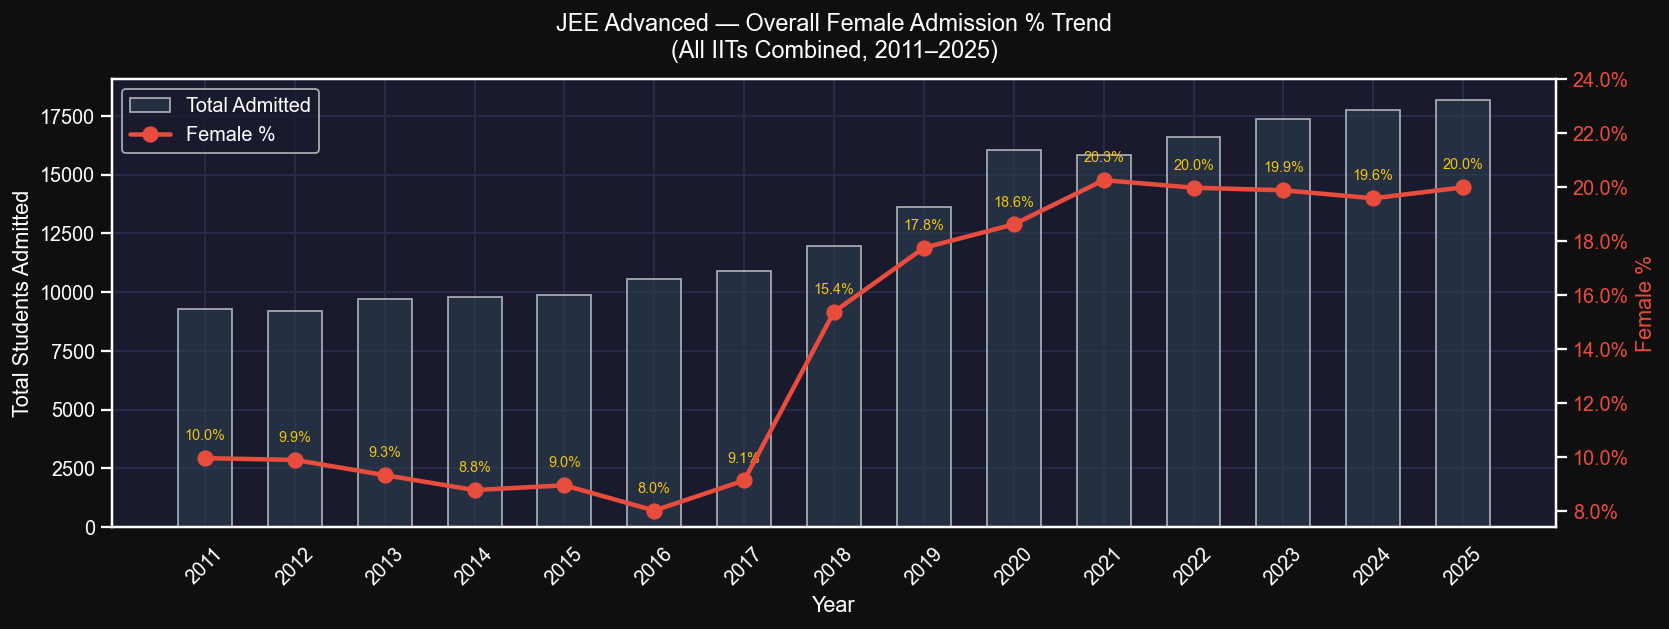

In [4]:
yearly = df.groupby("Year")[["Male", "Female", "Total"]].sum().reset_index()
yearly["Female_pct"] = (yearly["Female"] / yearly["Total"]) * 100

fig, ax1 = plt.subplots(figsize=(13, 5))

# Bar — total admissions
ax1.bar(yearly["Year"], yearly["Total"], color="#2c3e50", alpha=0.6, width=0.6, label="Total Admitted")
ax1.set_ylabel("Total Students Admitted", color="white")
ax1.set_xlabel("Year")

# Line — female %
ax2 = ax1.twinx()
ax2.plot(yearly["Year"], yearly["Female_pct"], color="#e74c3c", marker="o",
         linewidth=2.5, markersize=8, label="Female %", zorder=5)
ax2.set_ylabel("Female %", color="#e74c3c")
ax2.tick_params(axis="y", labelcolor="#e74c3c")
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))

# Annotate each point
for _, row in yearly.iterrows():
    ax2.annotate(f"{row['Female_pct']:.1f}%",
                 xy=(row["Year"], row["Female_pct"]),
                 xytext=(0, 10), textcoords="offset points",
                 ha="center", fontsize=8, color="#f1c40f")

ax1.set_title("JEE Advanced — Overall Female Admission % Trend\n(All IITs Combined, 2011–2025)", fontsize=13, pad=12)
ax1.set_xticks(yearly["Year"])
ax1.set_xticklabels(yearly["Year"], rotation=45)

y_min, y_max = ax2.get_ylim()
ax2.set_ylim(y_min, y_max * 1.15) # Adds 15% more headspace

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.grid(False)
plt.tight_layout()
plt.savefig("09_female_pct_trend.png", bbox_inches="tight")
plt.show()

BLOCK 4 — Stacked Bar: Male vs Female Each Year

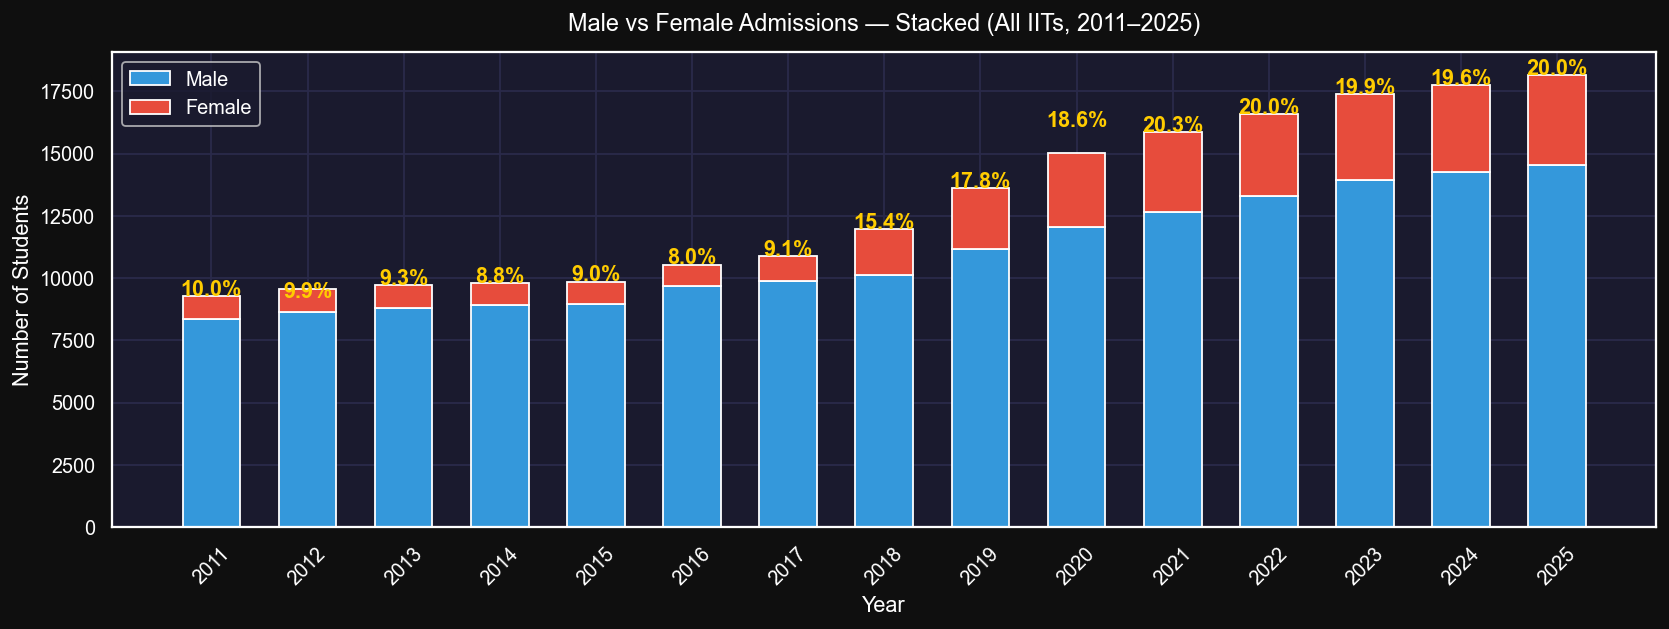

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(yearly["Year"], yearly["Male"], label="Male", color="#3498db", width=0.6)
ax.bar(yearly["Year"], yearly["Female"], bottom=yearly["Male"], label="Female", color="#e74c3c", width=0.6)

for _, row in yearly.iterrows():
    ax.text(row["Year"], row["Total"] + 20, f"{row['Female_pct']:.1f}%",
            ha="center", fontsize=12, color="#ffcc00", fontweight="bold")

ax.set_title("Male vs Female Admissions — Stacked (All IITs, 2011–2025)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Students")
ax.set_xticks(yearly["Year"])
ax.set_xticklabels(yearly["Year"], rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig("10_stacked_male_female.png", bbox_inches="tight")
plt.show()

BLOCK 5 — IIT-wise Female % Heatmap (Year × IIT)

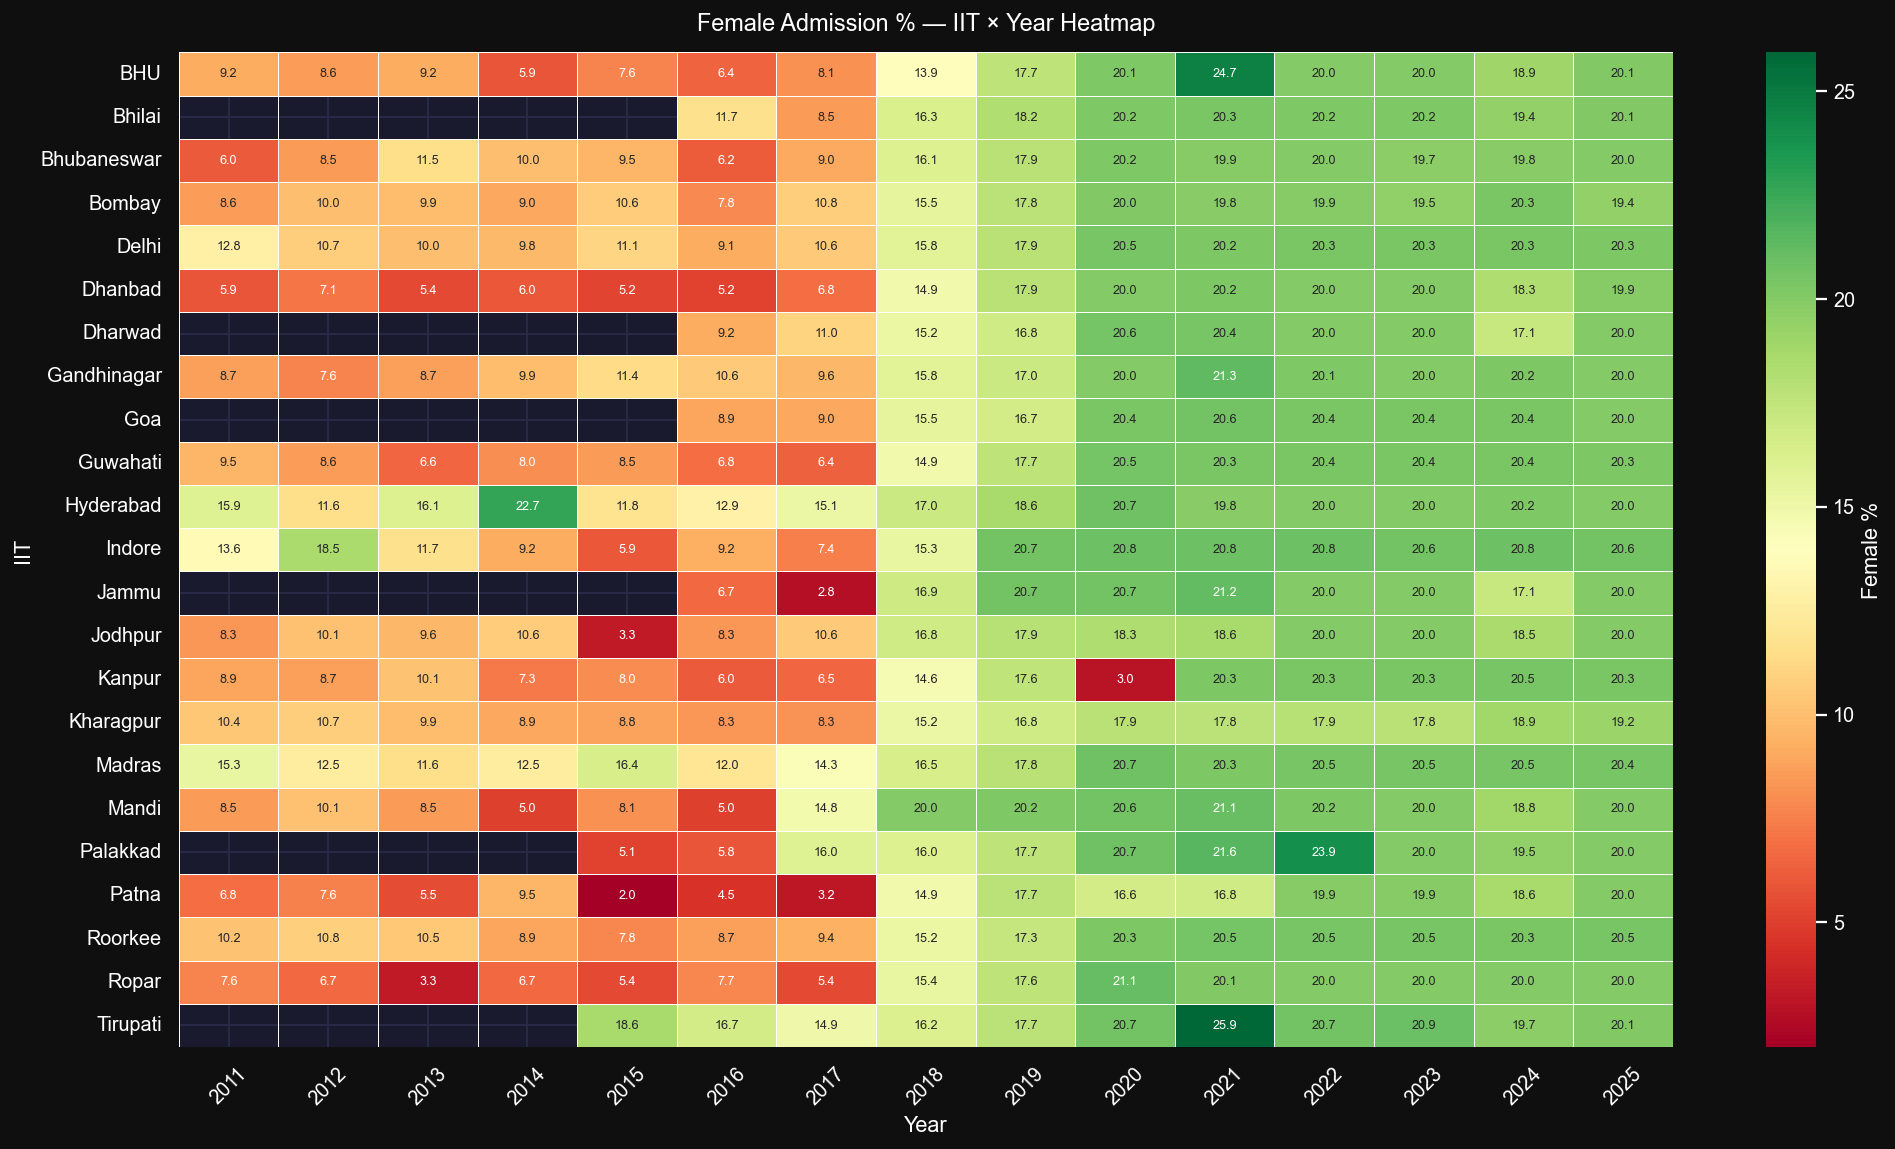

In [6]:
pivot = df.pivot_table(index="IIT Name", columns="Year", values="Female_pct", aggfunc="mean")

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.4, ax=ax, annot_kws={"size": 7},
            cbar_kws={"label": "Female %"})

ax.set_title("Female Admission % — IIT × Year Heatmap", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("IIT")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("11_iit_year_heatmap.png", bbox_inches="tight")
plt.show()

BLOCK 6 — Top & Bottom 5 IITs by All-time Female %

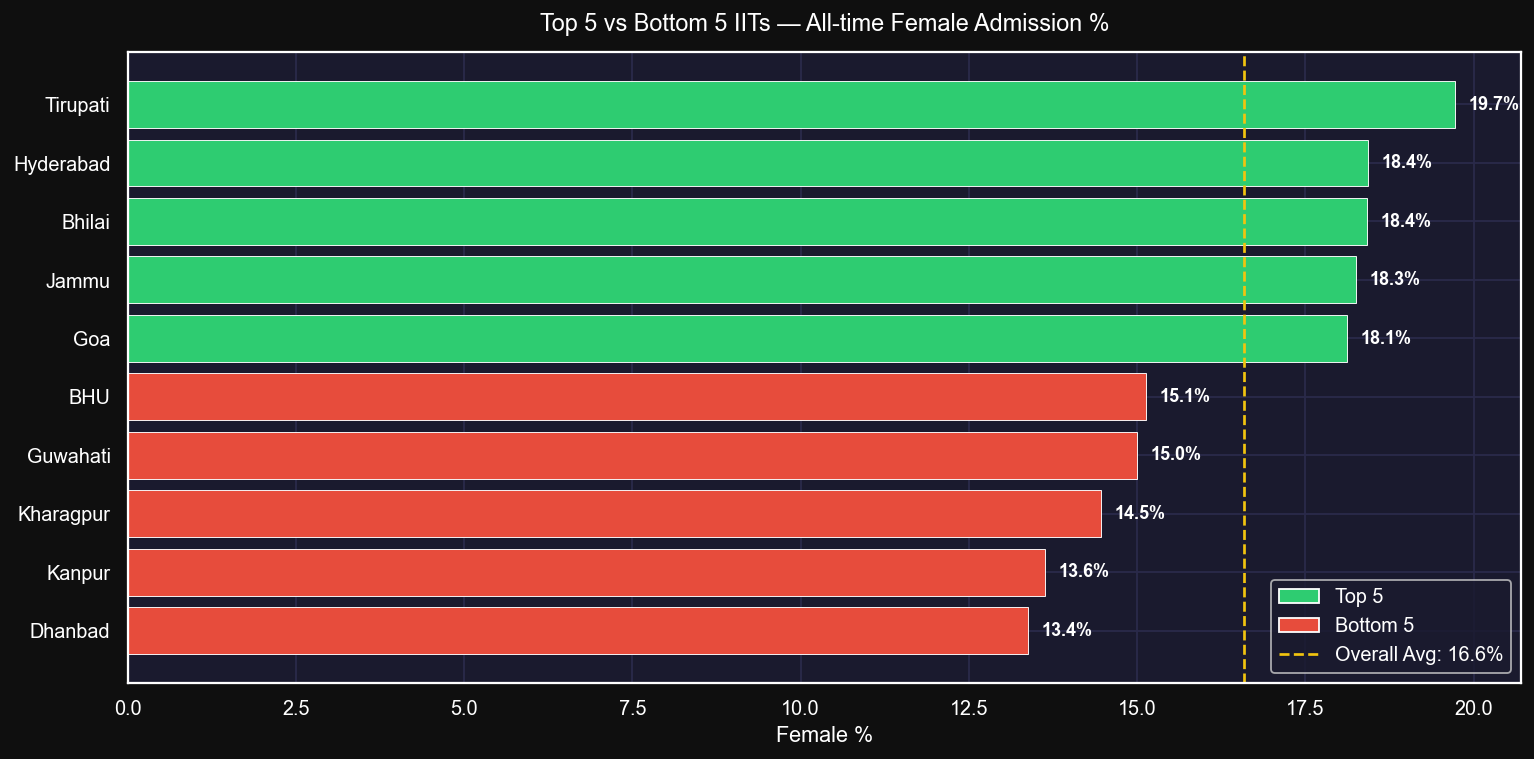

In [7]:
iit_summary = df.groupby("IIT Name").agg(
    Total_Female=("Female", "sum"),
    Total_Admitted=("Total", "sum")
).reset_index()
iit_summary["Female_pct"] = (iit_summary["Total_Female"] / iit_summary["Total_Admitted"]) * 100
iit_summary = iit_summary.sort_values("Female_pct", ascending=False)

top5    = iit_summary.head(5)
bottom5 = iit_summary.tail(5)
combined = pd.concat([top5, bottom5])

colors = ["#2ecc71"] * 5 + ["#e74c3c"] * 5

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(combined["IIT Name"], combined["Female_pct"], color=colors, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, combined["Female_pct"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10, color="white", fontweight="bold")

ax.set_title("Top 5 vs Bottom 5 IITs — All-time Female Admission %", fontsize=13, pad=12)
ax.set_xlabel("Female %")
ax.axvline(iit_summary["Female_pct"].mean(), color="#f1c40f", linestyle="--", linewidth=1.5, label=f"Overall Avg: {iit_summary['Female_pct'].mean():.1f}%")
ax.legend()
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_extra = [Patch(facecolor="#2ecc71", label="Top 5"), Patch(facecolor="#e74c3c", label="Bottom 5")]
ax.legend(handles=legend_extra + ax.get_legend_handles_labels()[0][-1:],
          labels=["Top 5", "Bottom 5", f"Overall Avg: {iit_summary['Female_pct'].mean():.1f}%"])

plt.tight_layout()
plt.savefig("12_top_bottom_iits.png", bbox_inches="tight")
plt.show()

BLOCK 7 — Female % Growth: Pre vs Post 2018 Reservation

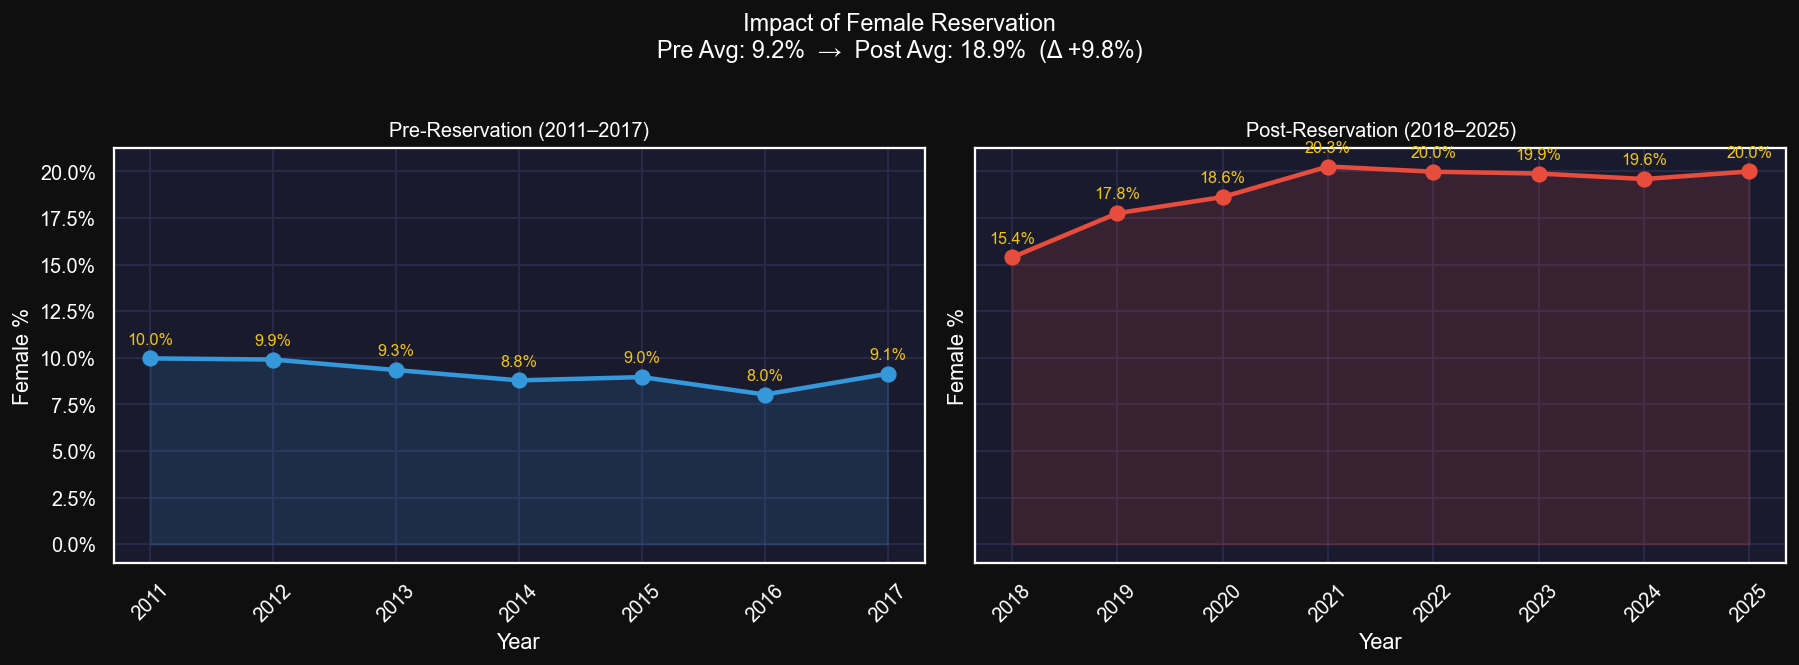

In [8]:
df["Era"] = df["Year"].apply(lambda y: "Pre-Reservation (2011–17)" if y < 2018 else "Post-Reservation (2018–25)")

era_summary = df.groupby(["Era", "Year"])[["Female", "Total"]].sum().reset_index()
era_summary["Female_pct"] = (era_summary["Female"] / era_summary["Total"]) * 100

pre  = era_summary[era_summary["Era"].str.startswith("Pre")]
post = era_summary[era_summary["Era"].str.startswith("Post")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, color, title in zip(
    axes,
    [pre, post],
    ["#3498db", "#e74c3c"],
    ["Pre-Reservation (2011–2017)", "Post-Reservation (2018–2025)"]
):
    ax.plot(data["Year"], data["Female_pct"], marker="o", color=color, linewidth=2.5, markersize=8)
    ax.fill_between(data["Year"], data["Female_pct"], alpha=0.15, color=color)
    for _, row in data.iterrows():
        ax.annotate(f"{row['Female_pct']:.1f}%",
                    xy=(row["Year"], row["Female_pct"]),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=9, color="#f1c40f")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Female %")
    ax.set_xticks(data["Year"])
    ax.set_xticklabels(data["Year"], rotation=45)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))

pre_avg  = pre["Female_pct"].mean()
post_avg = post["Female_pct"].mean()
fig.suptitle(f"Impact of Female Reservation\nPre Avg: {pre_avg:.1f}%  →  Post Avg: {post_avg:.1f}%  (Δ +{post_avg - pre_avg:.1f}%)",
             fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig("13_pre_post_reservation.png", bbox_inches="tight")
plt.show()

BLOCK 8 — IIT-wise Female % Over Time (Line per IIT — Major IITs)

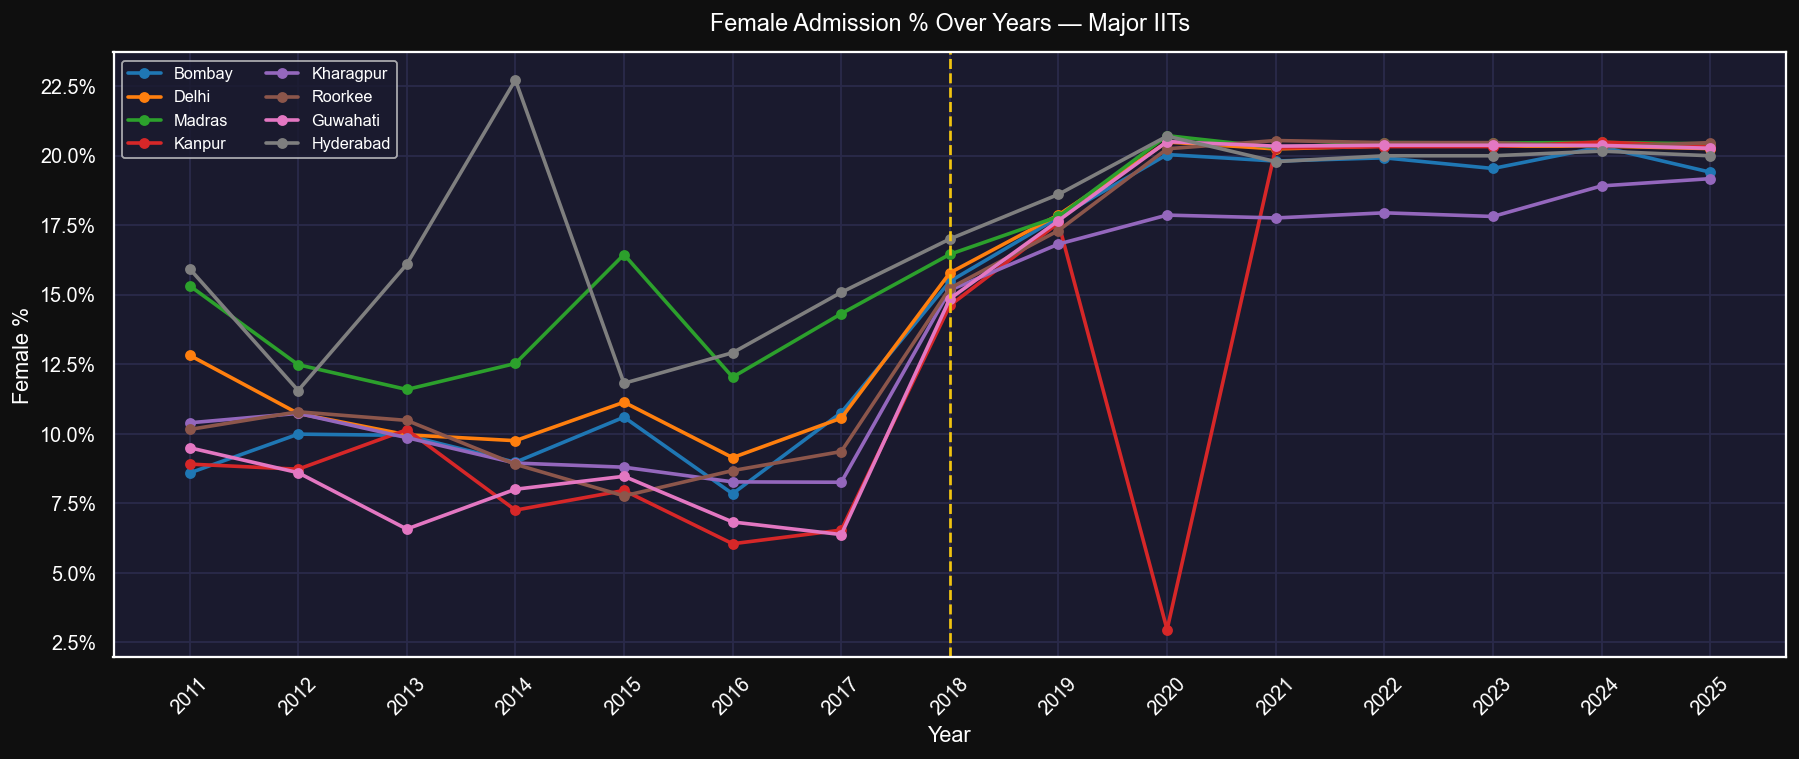

In [9]:
major_iits = ["Bombay", "Delhi", "Madras", "Kanpur", "Kharagpur", "Roorkee", "Guwahati", "Hyderabad"]
df_major = df[df["IIT Name"].isin(major_iits)]

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette("tab10", len(major_iits))
for iit, color in zip(major_iits, palette):
    data = df_major[df_major["IIT Name"] == iit].sort_values("Year")
    ax.plot(data["Year"], data["Female_pct"], marker="o", label=iit,
            linewidth=2, markersize=5, color=color)

ax.set_title("Female Admission % Over Years — Major IITs", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Female %")
ax.set_xticks(sorted(df["Year"].unique()))
ax.set_xticklabels(sorted(df["Year"].unique()), rotation=45)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.axvline(2018, color="#f1c40f", linestyle="--", linewidth=1.5, label="2018 Reservation")

plt.tight_layout()
plt.savefig("14_major_iits_female_trend.png", bbox_inches="tight")
plt.show()

In [21]:
import plotly.graph_objects as go

major_iits = ["Bombay", "Delhi", "Madras", "Kanpur", "Kharagpur", "Roorkee", "Guwahati", "Hyderabad"]
df_major = df[df["IIT Name"].isin(major_iits)]

fig = go.Figure()

# Add traces for each IIT
for iit in major_iits:
    data = df_major[df_major["IIT Name"] == iit].sort_values("Year")
    
    fig.add_trace(go.Scatter(
        x=data["Year"],
        y=data["Female_pct"],
        mode="lines+markers",
        name=iit,
        visible=True
    ))

# Create dropdown buttons
buttons = []

# Show ALL
buttons.append(dict(
    label="All",
    method="update",
    args=[{"visible": [True]*len(major_iits)},
          {"title": "Female Admission % — All IITs"}]
))

# Individual IIT buttons
for i, iit in enumerate(major_iits):
    visibility = [False] * len(major_iits)
    visibility[i] = True
    
    buttons.append(dict(
        label=iit,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Female Admission % — {iit}"}]
    ))

# Update layout
fig.update_layout(
    template="plotly_dark",
    title="Female Admission % Over Years — Major IITs",
    xaxis_title="Year",
    yaxis_title="Female %",
    
    # 👉 Move dropdown ABOVE the plot
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.2,
        y=1.25,
        xanchor="right",
        yanchor="top"
    )],
)
# Format Y-axis as %
fig.update_yaxes(ticksuffix="%")

# Add vertical line for 2018
fig.add_vline(
    x=2018,
    line_dash="dash",
    line_color="yellow",
    annotation_text="2018 Reservation",
    annotation_position="top"
)
fig.write_html("female.html")
fig.show()

BLOCK 9 — Summary Stats Print

In [11]:
yearly = df.groupby("Year")[["Male", "Female", "Total"]].sum().reset_index()
yearly["Female_pct"] = (yearly["Female"] / yearly["Total"]) * 100

print("=" * 60)
print("     MALE-FEMALE ADMISSION — KEY INSIGHTS SUMMARY")
print("=" * 60)
print(f"Total Years Covered    : {df['Year'].min()} – {df['Year'].max()}")
print(f"Total IITs Covered     : {df['IIT Name'].nunique()}")
print(f"Total Students (All)   : {df['Total'].sum():,}")
print(f"Total Female Admitted  : {df['Female'].sum():,}")
print(f"Overall Female %       : {(df['Female'].sum()/df['Total'].sum()*100):.2f}%")
print(f"Pre-2018 Avg Female %  : {yearly[yearly['Year']<2018]['Female_pct'].mean():.2f}%")
print(f"Post-2018 Avg Female % : {yearly[yearly['Year']>=2018]['Female_pct'].mean():.2f}%")
print(f"Best Year (Female %)   : {int(yearly.loc[yearly['Female_pct'].idxmax(),'Year'])} → {yearly['Female_pct'].max():.2f}%")
print(f"Worst Year (Female %)  : {int(yearly.loc[yearly['Female_pct'].idxmin(),'Year'])} → {yearly['Female_pct'].min():.2f}%")
print("=" * 60)

     MALE-FEMALE ADMISSION — KEY INSIGHTS SUMMARY
Total Years Covered    : 2011 – 2025
Total IITs Covered     : 23
Total Students (All)   : 196,654
Total Female Admitted  : 30,681
Overall Female %       : 15.60%
Pre-2018 Avg Female %  : 9.17%
Post-2018 Avg Female % : 18.94%
Best Year (Female %)   : 2021 → 20.27%
Worst Year (Female %)  : 2016 → 8.03%
